In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve
from copy import deepcopy

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
x = torch.from_numpy(np.load("/content/drive/MyDrive/commentData_sbert_embeddings_TitleComment.npy"))
y = torch.from_numpy(np.load("/content/drive/MyDrive/commentData_labels_TitleComment.npy")).unsqueeze(1).float()

<h1>데이터 전처리</h1>

In [ ]:
x_np = x.numpy()
y_np = y.numpy().reshape(-1)

print(np.shape(x_np), np.shape(y_np))
x_train_np, x_temp_np, y_train_np, y_temp_np = train_test_split(
    x_np, y_np, test_size=0.15, stratify=y_np, random_state=42
)

x_valid_np, x_test_np, y_valid_np, y_test_np = train_test_split(
    x_temp_np, y_temp_np, test_size=0.5, stratify=y_temp_np, random_state=42
)

x_train = torch.tensor(x_train_np, dtype=torch.float32)
x_valid = torch.tensor(x_valid_np, dtype=torch.float32)
x_test  = torch.tensor(x_test_np, dtype=torch.float32)

y_train = torch.tensor(y_train_np, dtype=torch.float32).view(-1,1)
y_valid = torch.tensor(y_valid_np, dtype=torch.float32).view(-1,1)
y_test  = torch.tensor(y_test_np, dtype=torch.float32).view(-1,1)

# Train / Valid / Test = 0.85 0.075 0.075
print("Train / Valid / Test = ", x_train.size(0), x_valid.size(0), x_test.size(0))


(3924, 768) (3924,)
Train / Valid / Test =  3335 294 295


<h1>모델</h1>

In [ ]:
class MyModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.BatchNorm1d(32),
            nn.SiLU(),
            nn.Dropout(0.1),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.layers(x)

model = MyModel(input_dim=x_train.size(1))

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=0
)

crit = nn.BCEWithLogitsLoss()

batch_size = 512

'\nclass MyModel(nn.Module):\n    def __init__(self, input_dim):\n        super().__init__()\n        self.layers = nn.Sequential(\n            nn.Linear(input_dim, 64),\n            nn.BatchNorm1d(64),\n            nn.ReLU(),\n            nn.Dropout(0.1),\n            nn.Linear(64, 1)\n        )\n\n    def forward(self, x):\n        return self.layers(x)\n\nmodel = MyModel(input_dim=x_train.size(1))\n\noptimizer = torch.optim.Adam(\n    model.parameters(),\n    lr=3e-4,\n    weight_decay=0.01\n)\n\ncrit = nn.BCEWithLogitsLoss()\nbatch_size = 64\n\n\nclass MyModel(nn.Module):\n    def __init__(self, input_dim):\n        super().__init__()\n        self.layers = nn.Sequential(\n            nn.Linear(input_dim, 128),\n            nn.BatchNorm1d(128),\n            nn.LeakyReLU(),\n            nn.Dropout(0.5),\n            nn.Linear(128, 64),\n            nn.BatchNorm1d(64),\n            nn.LeakyReLU(),\n            nn.Dropout(0.2),\n            nn.Linear(64, 1)\n        )\n\n    def forwa

<h1> Train </h1>

In [ ]:
n_epochs = 200
early_stop = 20
print_interval = 10

lowest_loss = np.inf
lowest_epoch = 0
best_model = None

train_history, valid_history = [], []

for epoch in range(n_epochs):
    model.train()
    indices = torch.randperm(x_train.size(0))
    x_train_shuffled = x_train[indices]
    y_train_shuffled = y_train[indices]

    train_loss = 0
    for i in range(0, x_train.size(0), batch_size):
        x_batch = x_train_shuffled[i:i+batch_size]
        y_batch = y_train_shuffled[i:i+batch_size]

        optimizer.zero_grad()
        y_hat = model(x_batch)
        loss = crit(y_hat, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * x_batch.size(0)

    train_loss /= x_train.size(0)

    # ---- Validation ----
    model.eval()
    valid_loss = 0
    with torch.no_grad():
        for i in range(0, x_valid.size(0), batch_size):
            x_batch = x_valid[i:i+batch_size]
            y_batch = y_valid[i:i+batch_size]
            y_hat = model(x_batch)
            loss = crit(y_hat, y_batch)
            valid_loss += loss.item() * x_batch.size(0)
    valid_loss /= x_valid.size(0)

    train_history.append(train_loss)
    valid_history.append(valid_loss)

    # ---- Logging ----
    if (epoch+1) % print_interval == 0:
        print(f"Epoch {epoch+1}: train_loss={train_loss:.4e} valid_loss={valid_loss:.4e} lowest={lowest_loss:.4e}")

    # ---- Early stopping ----
    if valid_loss < lowest_loss:
        lowest_loss = valid_loss
        lowest_epoch = epoch
        best_model = deepcopy(model.state_dict())
    elif epoch - lowest_epoch >= early_stop:
        print(f"No improvement for {early_stop} epochs. Stopping at epoch {epoch+1}")
        break


Epoch 10: train_loss=3.2165e-01 valid_loss=3.0344e-01 lowest=3.1362e-01
Epoch 20: train_loss=2.5177e-01 valid_loss=2.4397e-01 lowest=2.4873e-01
Epoch 30: train_loss=2.1552e-01 valid_loss=2.1329e-01 lowest=2.1583e-01
Epoch 40: train_loss=1.9027e-01 valid_loss=1.9067e-01 lowest=1.9280e-01
Epoch 50: train_loss=1.7040e-01 valid_loss=1.7224e-01 lowest=1.7405e-01
Epoch 60: train_loss=1.5368e-01 valid_loss=1.5748e-01 lowest=1.5938e-01
Epoch 70: train_loss=1.3937e-01 valid_loss=1.4459e-01 lowest=1.4579e-01
Epoch 80: train_loss=1.2720e-01 valid_loss=1.3360e-01 lowest=1.3371e-01
Epoch 90: train_loss=1.1567e-01 valid_loss=1.2310e-01 lowest=1.2390e-01
Epoch 100: train_loss=1.0634e-01 valid_loss=1.1411e-01 lowest=1.1451e-01
Epoch 110: train_loss=9.7461e-02 valid_loss=1.0599e-01 lowest=1.0664e-01
Epoch 120: train_loss=8.9415e-02 valid_loss=9.8921e-02 lowest=9.9475e-02
Epoch 130: train_loss=8.3550e-02 valid_loss=9.3219e-02 lowest=9.3344e-02
Epoch 140: train_loss=7.5645e-02 valid_loss=8.7349e-02 lowes

<h1> 성능 </h1>

Best validation loss: 6.3001e-02 at epoch 199


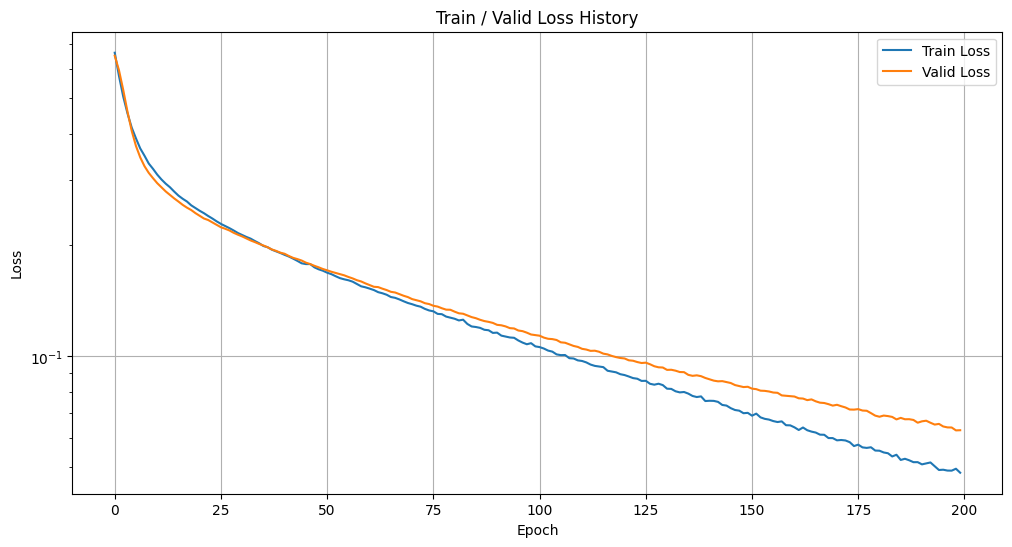


Optimal threshold on valid set: 0.62 with F1=0.9966

=== Test Performance (optimal threshold) ===
Accuracy : 0.9898
Precision: 1.0000
Recall   : 0.9795
F1-score : 0.9896
ROC AUC  : 0.9994


In [ ]:
model.load_state_dict(best_model)
print(f"Best validation loss: {lowest_loss:.4e} at epoch {lowest_epoch+1}")

plt.figure(figsize=(12,6))
plt.plot(train_history, label='Train Loss')
plt.plot(valid_history, label='Valid Loss')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train / Valid Loss History')
plt.grid(True)
plt.legend()
plt.show()

model.eval()
with torch.no_grad():
    y_hat_test = model(x_test)
    y_prob_test = torch.sigmoid(y_hat_test).numpy()
    y_true_test = y_test.numpy()

    y_hat_val = model(x_valid)
    y_prob_val = torch.sigmoid(y_hat_val).numpy()
    y_true_val = y_valid.numpy()

# Optimal threshold (F1 기준)
thresholds = np.linspace(0.01,0.99,99)
best_f1 = 0
best_thresh = 0.5
for t in thresholds:
    y_val_pred = (y_prob_val > t).astype(int)
    f1 = f1_score(y_true_val, y_val_pred)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t
print(f"\nOptimal threshold on valid set: {best_thresh:.2f} with F1={best_f1:.4f}")

# Test performance at optimal threshold
y_pred_opt = (y_prob_test > best_thresh).astype(int)
print("\n=== Test Performance (optimal threshold) ===")
print(f"Accuracy : {accuracy_score(y_true_test, y_pred_opt):.4f}")
print(f"Precision: {precision_score(y_true_test, y_pred_opt):.4f}")
print(f"Recall   : {recall_score(y_true_test, y_pred_opt):.4f}")
print(f"F1-score : {f1_score(y_true_test, y_pred_opt):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_true_test, y_prob_test):.4f}")

<h1> 모델 저장 </h1>

In [ ]:
torch.save(model.state_dict(), 'comment_classifier.pth')
print("\n모델 저장 완료: comment_classifier.pth")


모델 저장 완료: comment_classifier.pth


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.load_state_dict(torch.load('/content/comment_classifier.pth', map_location=device))
# model.load_state_dict(torch.load('/content/drive/MyDrive/comment_classifier.pth', map_location=device))
model.eval()
model.to(device)

MyModel(
  (layers): Sequential(
    (0): Linear(in_features=768, out_features=32, bias=True)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): SiLU()
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)

<h1> 모델 테스트 </h1>

In [ ]:
from sentence_transformers import SentenceTransformer
sbert_model = SentenceTransformer('snunlp/KR-SBERT-V40K-klueNLI-augSTS')

pytorch_model.bin:   0%|          | 0.00/467M [00:00<?, ?B/s]

In [ ]:
def predict_comment(text, threshold=0.5):
    # 1. 임베딩
    embedding = sbert_model.encode(text, convert_to_tensor=True).cpu()
    x = embedding.unsqueeze(0)

    # 2. 예측
    model.eval()
    with torch.no_grad():
        logit = model(x)
        prob = torch.sigmoid(logit).item()

    # 3. 레이블 결정
    label = 1 if prob >= threshold else 0
    label_str = "봇" if label == 1 else "인간"

    return {
        "text": text,
        "probability": round(prob, 4),
        "prediction": label_str,
        "is_malicious": label
    }


In [ ]:
if __name__ == "__main__":
    test_comments = [
        # "장동혁 “갈라지고 흩어져 계엄도 탄핵도 못 막았다” 니들이 지금 지지율이 낮은건 탄핵을 못막아서가 아니라 탄핵을 막으려고 했었기 때문이야. 윤석열 계엄 했을때 바로 탄핵 추진하고 나가라고 발로 걷어찼어야지. 제정신 아닌거 확인하고도 왜 옹호를 하냐? 지금 국힘 지지 안하는 사람들이 윤석열 탄핵 못막아서 실망한 사람들일까? 지금 본인 지지층이 윤어게인이잖아. 나간 사람은 윤어게인 아닌 사람들이 나갔겠지. 그럼 뭘 죄송해 해야 되겠냐?",
        # "장동혁 “갈라지고 흩어져 계엄도 탄핵도 못 막았다” 계엄도 못막고 탄핵도 못막았어 국민에게 죄송하다고 이게 무슨 해괴한 논리인가 계엄을 안 했으면 탄핵이 없었을 일인데 ㆍㆍㆍ 짱동혁이가 요즘 제정신이 아니네",
        # "장동혁 “갈라지고 흩어져 계엄도 탄핵도 못 막았다” 장동혁 니가 지금하고있는 말과 행동이 국민의힘을 흩어지고 갈라지게 하고있다. 이러다간 내년 지선에서 망한다. 정신차려라. 한입으로 두말하네 너네는 내란당이다 니네가 내세우는 대통령은 수틀리면 또 계엄을 할것이고 니네당 국회의원은 옹호하겠지 니네당이 꿈꾸는 나라는 태국,미얀마 니네만 잘사는 나라 올해내내 한게 도대체뭐지?",
        # "장동혁 “갈라지고 흩어져 계엄도 탄핵도 못 막았다” 입으로 배설하는구나",
        # "장동혁 “갈라지고 흩어져 계엄도 탄핵도 못 막았다” “장 대표님, ‘갈라지고 흩어져서’라며 지금 당면한 위기와 과거를 연결지어 말씀하셨는데, 과연 ‘분열’이 문제라면 이제부터는 ‘단합’이 해결책이 될까요? 12·3 계엄이 옳았다고 주장하는 목소리도 있지만, 그 한계와 비극을 잊지 않으면서 우리 당이 어떻게 앞으로 나아가야 할지 구체적인 전략이 필요합니다. 내부 총질이 아니라 ‘통합적 방안’이 먼저라 생각합니다.",
        # "장동혁 “갈라지고 흩어져 계엄도 탄핵도 못 막았다” “정치가 무너졌다고 느끼는 순간이 오면, 무조건 ‘계엄’이 정당화되는 건 아닙니다. 우리는 비상계엄이 가져온 혼란과 인권 침해를 깊이 인식해야 해요. 장 대표님이 말한 ‘모두 하나로 뭉쳐야 한다’는 게 진짜라면, 민주주의를 지키는 방법을 재정의하고, 국민의 뜻을 제대로 듣는 조직 구조를 만들어야 합니다. ‘계엄을 두고 논쟁’이 아니라 ‘정책을 두고 논쟁’이 되어야 합니다.",
        # "장동혁 “갈라지고 흩어져 계엄도 탄핵도 못 막았다” 장 대표가 “분열”이 문제라며 단합을 호소하지만, 실제 현장에서는 ‘계엄은 옳았다’는 항의와 사과 요구가 동시에 뜨거웠습니다. 과거를 객관적으로 되짚고, 앞으로는 민주주의와 인권을 최우선으로 한 구체적 방안을 제시해야 할 때입니다.",
        # "장동혁 “갈라지고 흩어져 계엄도 탄핵도 못 막았다” 분열을 단속했지만 현장엔 ‘계엄 옳았다’ 항의와 사과 요구가 동시에 일어났다. 과거를 반성하고, 미래는 민주주의·인권을 최우선으로 해야 한다.",
        # "장동혁 “갈라지고 흩어져 계엄도 탄핵도 못 막았다” 장동혁 의원님 말 100% 공감합니다. 흩어져서 계엄도 막지 못하고, 탄핵도 막지 못하고, 결국 이재명 정권 만들어준 게 바로 내부 총질한 놈들 때문이잖아요. 이제라도 정신 차리고 하나로 뭉칩시다. 또 싸우다간 진짜 나라 망한다.",
        # "장동혁 “갈라지고 흩어져 계엄도 탄핵도 못 막았다” 당 내부에서 뭐가 문제였는지 서로 인정도 못 하면서 단결 운운하는 게 더 혼란스럽다. 책임 회피만 반복되니 신뢰가 쌓일 리가 있나.",
        # "장동혁 “갈라지고 흩어져 계엄도 탄핵도 못 막았다” 사과하라는 사람, 사과 그만하라는 사람, 계엄이 맞았다라는 사람… 의견이 셋이면 정리가 안 되는 건 당연하다. 내부 정돈부터 하고 민생 얘기를 해야지.",
        # "장동혁 “갈라지고 흩어져 계엄도 탄핵도 못 막았다” “하나로 뭉쳐야 한다!” 외치는 순간 옆에서 “계엄 정당했다!” “내려와라!” 고성 나오는 거 실화냐. 개판 그 자체.",
        # "장동혁 “갈라지고 흩어져 계엄도 탄핵도 못 막았다” 12·3 계엄은 헌법 77조에 따른 완벽히 적법한 조치였습니다.사과? 절대 안 됩니다. 오히려 탄핵 무효 소송하고 윤석열 대통령 복권시켜야죠. 윤어게인!!",
        # "장동혁 “갈라지고 흩어져 계엄도 탄핵도 못 막았다” 장동혁 대표의 '갈라지고 흩어져서 계엄도 탄핵도 못 막았다'는 호소는 충분히 공감한다. 하지만 지금 이 기사에서처럼, 당장 눈앞의 계엄 사태에 대한 평가조차 통일되지 못하고 서로 고성을 주고받는 상황에서 '단결'이 가능할지 의문이다. 내부 혼란부터 수습해야 이재명 정권 견제도 가능하지 않겠나.",
        # "장동혁 “갈라지고 흩어져 계엄도 탄핵도 못 막았다” 엄태영 위원장의 '윤석열 전 대통령과 절연하고 재창당 수준으로 혁신해야 지방선거를 이길 수 있다'는 지적은 현실적이다. 국민들 눈높이에서 볼 때, 계엄 사태에 대한 명확한 반성과 선 긋기가 없으면 보수층조차 지지를 망설일 것이다. 그를 향해 '계엄은 정당했다'고 외치는 사람들이 있다면, 그들이야말로 당의 미래를 막는 사람들이다.",
    ]

    print("봇 탐지기 테스트\n" + "="*50)
    for comment in test_comments:
        result = predict_comment(comment, threshold=0.5)
        print(f"입력: {result['text']}")
        print(f"예측: {result['prediction']} (확률: {result['probability']})")
        print("-" * 50)

봇 탐지기 테스트
입력: 장동혁 “갈라지고 흩어져 계엄도 탄핵도 못 막았다” 장동혁 의원님 말 100% 공감합니다. 흩어져서 계엄도 막지 못하고, 탄핵도 막지 못하고, 결국 이재명 정권 만들어준 게 바로 내부 총질한 놈들 때문이잖아요. 이제라도 정신 차리고 하나로 뭉칩시다. 또 싸우다간 진짜 나라 망한다.
예측: 인간 (확률: 0.4946)
--------------------------------------------------
입력: 장동혁 “갈라지고 흩어져 계엄도 탄핵도 못 막았다” 당 내부에서 뭐가 문제였는지 서로 인정도 못 하면서 단결 운운하는 게 더 혼란스럽다. 책임 회피만 반복되니 신뢰가 쌓일 리가 있나.
예측: 봇 (확률: 0.9523)
--------------------------------------------------
입력: 장동혁 “갈라지고 흩어져 계엄도 탄핵도 못 막았다” 사과하라는 사람, 사과 그만하라는 사람, 계엄이 맞았다라는 사람… 의견이 셋이면 정리가 안 되는 건 당연하다. 내부 정돈부터 하고 민생 얘기를 해야지.
예측: 봇 (확률: 0.9422)
--------------------------------------------------
입력: 장동혁 “갈라지고 흩어져 계엄도 탄핵도 못 막았다” “하나로 뭉쳐야 한다!” 외치는 순간 옆에서 “계엄 정당했다!” “내려와라!” 고성 나오는 거 실화냐. 개판 그 자체.
예측: 인간 (확률: 0.0531)
--------------------------------------------------
입력: 장동혁 “갈라지고 흩어져 계엄도 탄핵도 못 막았다” 12·3 계엄은 헌법 77조에 따른 완벽히 적법한 조치였습니다.사과? 절대 안 됩니다. 오히려 탄핵 무효 소송하고 윤석열 대통령 복권시켜야죠. 윤어게인!!
예측: 인간 (확률: 0.0589)
--------------------------------------------------
입력: 장동혁 “갈라지고 흩어져 계엄도 탄핵도 못 막았

<h1>무작위 검색 방식 </h1>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from copy import deepcopy
from sklearn.metrics import f1_score
import random

# Seed 고정
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

ACTS = {
    "relu": nn.ReLU,
    "gelu": nn.GELU,
    "silu": nn.SiLU,
    "leaky": lambda: nn.LeakyReLU(0.1)
}

OPTIMS = {
    "adam": optim.Adam,
    "adamw": optim.AdamW,
    "radam": optim.RAdam,
    "sgd": optim.SGD,
}

HIDDEN_DIMS = [32, 64, 128, 256, 512]
HIDDEN_LAYERS = [1, 2, 3, 4, 5]
DROP_RATES = [0.0, 0.1, 0.2, 0.3]
LR_LIST = [1e-4, 3e-4, 1e-3, 3e-3]
WD_LIST = [0, 1e-4, 1e-3, 1e-2]
BATCH_SIZES = [32, 64, 128, 256, 512]
USE_BN = [True, False]

MAX_TRIALS = 100
EARLY_STOP = 20
N_EPOCHS = 200

class DynamicModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, n_layers, activation, dropout, use_bn):
        super().__init__()
        act = ACTS[activation]

        layers = []
        prev = input_dim

        for _ in range(n_layers):
            layers.append(nn.Linear(prev, hidden_dim))
            if use_bn:
                layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(act())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev = hidden_dim

        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

def train_and_eval(x_train, y_train, x_valid, y_valid, trial_cfg):
    model = DynamicModel(
        input_dim=x_train.size(1),
        hidden_dim=trial_cfg["hidden_dim"],
        n_layers=trial_cfg["n_layers"],
        activation=trial_cfg["act"],
        dropout=trial_cfg["drop"],
        use_bn=trial_cfg["bn"]
    )

    opt_class = OPTIMS[trial_cfg["optim"]]
    optimizer = opt_class(model.parameters(),
                          lr=trial_cfg["lr"],
                          weight_decay=trial_cfg["wd"])

    crit = nn.BCEWithLogitsLoss() 
    batch_size = trial_cfg["bs"]

    lowest_loss = np.inf
    best_state = None
    no_improve = 0

    for epoch in range(N_EPOCHS):
        model.train()

        x_shuf = x_train
        y_shuf = y_train

        for i in range(0, x_train.size(0), batch_size):
            xb = x_shuf[i:i+batch_size]
            yb = y_shuf[i:i+batch_size]

            optimizer.zero_grad()
            out = model(xb)
            loss = crit(out, yb)
            loss.backward()
            optimizer.step()

        # validation
        model.eval()
        with torch.no_grad():
            val_out = model(x_valid)
            val_loss = crit(val_out, y_valid).item()

        if val_loss < lowest_loss:
            lowest_loss = val_loss
            best_state = deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1

        if no_improve >= EARLY_STOP:
            break

    model.load_state_dict(best_state)
    model.eval()

    with torch.no_grad():
        probs = torch.sigmoid(model(x_valid)).numpy()
        preds = (probs > 0.5).astype(int)
        f1 = f1_score(y_valid.numpy(), preds)

    return f1, lowest_loss, trial_cfg, deepcopy(model.state_dict())

best_f1 = -1
best_model = None
best_cfg = None

for t in range(MAX_TRIALS):
    cfg = {
        "hidden_dim": random.choice(HIDDEN_DIMS),
        "n_layers": random.choice(HIDDEN_LAYERS),
        "act": random.choice(list(ACTS.keys())),
        "drop": random.choice(DROP_RATES),
        "bn": random.choice(USE_BN),
        "optim": random.choice(list(OPTIMS.keys())),
        "lr": random.choice(LR_LIST),
        "wd": random.choice(WD_LIST),
        "bs": random.choice(BATCH_SIZES)
    }

    f1, loss, cfg, model_state = train_and_eval(
        x_train, y_train, x_valid, y_valid, cfg
    )

    print(f"[Trial {t+1}/{MAX_TRIALS}] F1={f1:.4f} cfg={cfg}")

    if f1 > best_f1:
        best_f1 = f1
        best_cfg = cfg
        best_model = model_state

print("\n============= BEST RESULT =============")
print("Best F1:", best_f1)
print("Best Config:", best_cfg)


[Trial 1/100] F1=0.9966 cfg={'hidden_dim': 32, 'n_layers': 1, 'act': 'silu', 'drop': 0.1, 'bn': True, 'optim': 'adamw', 'lr': 0.0001, 'wd': 0, 'bs': 512}
[Trial 2/100] F1=0.9932 cfg={'hidden_dim': 256, 'n_layers': 1, 'act': 'relu', 'drop': 0.0, 'bn': True, 'optim': 'adamw', 'lr': 0.0001, 'wd': 0.0001, 'bs': 512}
[Trial 3/100] F1=0.9863 cfg={'hidden_dim': 256, 'n_layers': 2, 'act': 'leaky', 'drop': 0.2, 'bn': True, 'optim': 'adamw', 'lr': 0.003, 'wd': 0.001, 'bs': 128}
[Trial 4/100] F1=0.9448 cfg={'hidden_dim': 64, 'n_layers': 2, 'act': 'silu', 'drop': 0.0, 'bn': True, 'optim': 'sgd', 'lr': 0.0001, 'wd': 0.001, 'bs': 128}
[Trial 5/100] F1=0.8364 cfg={'hidden_dim': 512, 'n_layers': 3, 'act': 'relu', 'drop': 0.3, 'bn': True, 'optim': 'sgd', 'lr': 0.0001, 'wd': 0.001, 'bs': 512}
[Trial 6/100] F1=0.9829 cfg={'hidden_dim': 128, 'n_layers': 5, 'act': 'gelu', 'drop': 0.0, 'bn': True, 'optim': 'adamw', 'lr': 0.001, 'wd': 0, 'bs': 64}
[Trial 7/100] F1=0.9795 cfg={'hidden_dim': 32, 'n_layers': 4,

In [ ]:
model.eval()
with torch.no_grad():
    out = model(x_test)
    probs = torch.sigmoid(out).cpu().numpy()
    preds = (probs > 0.5).astype(int)

from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test.numpy(), preds))
print("Test ROC AUC:", roc_auc_score(y_test.numpy(), probs))


              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99       149
         1.0       1.00      0.98      0.99       146

    accuracy                           0.99       295
   macro avg       0.99      0.99      0.99       295
weighted avg       0.99      0.99      0.99       295

Test ROC AUC: 0.9994024087524134
